In [2]:
import pandas as pd
import numpy as np
import re

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
import os
print(os.getcwd())

C:\Users\hp\AI Resume Analyzer


# adding a job set

In [3]:
jobs = pd.DataFrame({
    "Job Title": [
        "Data Analyst",
        "Machine Learning Engineer",
        "Data Scientist",
        "Python Developer",
        "AI/ML Intern"
    ],
    
    "Skills": [
        "Python, SQL, Excel, Power BI, Pandas",
        "Python, Machine Learning, Scikit-learn, TensorFlow, Git",
        "Python, Pandas, NumPy, Machine Learning, Statistics",
        "Python, Flask, SQL, Git, REST API",
        "Python, Machine Learning, Pandas, NumPy, Git"
    ]
})

jobs

,Job Title,Skills
0,Data Analyst,"Python, SQL, Excel, Power BI, Pandas"
1,Machine Learning Engineer,"Python, Machine Learning, Scikit-learn, Tensor..."
2,Data Scientist,"Python, Pandas, NumPy, Machine Learning, Stati..."
3,Python Developer,"Python, Flask, SQL, Git, REST API"
4,AI/ML Intern,"Python, Machine Learning, Pandas, NumPy, Git"


# resume

In [4]:
resume = """
I am a B.Tech CSE AIML student with knowledge of Python,
Machine Learning, Pandas, NumPy, SQL and Data Analysis.

I have developed a machine learning project for waste prediction.
I have also worked on data analytics projects and used
Scikit-learn for building machine learning models.

I have good problem solving and communication skills.
"""

print(resume)


I am a B.Tech CSE AIML student with knowledge of Python,
Machine Learning, Pandas, NumPy, SQL and Data Analysis.

I have developed a machine learning project for waste prediction.
I have also worked on data analytics projects and used
Scikit-learn for building machine learning models.

I have good problem solving and communication skills.



In [5]:
##creating skills
skills = [
    "python",
    "sql",
    "machine learning",
    "pandas",
    "numpy",
    "data analysis",
    "scikit-learn",
    "tensorflow",
    "power bi",
    "excel",
    "flask",
    "git",
    "communication",
    "problem solving"
]

In [6]:
resume_lower = resume.lower()

found_skills = []

for skill in skills:
    if skill in resume_lower:
        found_skills.append(skill)

print("Skills found in resume:")
print(found_skills)

Skills found in resume:
['python', 'sql', 'machine learning', 'pandas', 'numpy', 'data analysis', 'scikit-learn', 'communication', 'problem solving']


# Job Matching using TF-IDF + Cosine Similarity

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# creating a job description

In [8]:
jobs["Job Description"] = [
    "Analyze business data, create reports and dashboards, clean datasets and find useful insights using Python, SQL, Pandas and Excel.",
    
    "Build and evaluate machine learning models, prepare datasets and develop AI solutions using Python, Machine Learning, Scikit-learn and TensorFlow.",
    
    "Analyze large datasets, build predictive models and communicate insights using Python, Pandas, NumPy, Machine Learning and Statistics.",
    
    "Develop backend applications and REST APIs using Python, Flask, SQL and Git.",
    
    "Assist with machine learning experiments, data preprocessing and model development using Python, Machine Learning, Pandas, NumPy and Git."
]

jobs

,Job Title,Skills,Job Description
0,Data Analyst,"Python, SQL, Excel, Power BI, Pandas","Analyze business data, create reports and dash..."
1,Machine Learning Engineer,"Python, Machine Learning, Scikit-learn, Tensor...","Build and evaluate machine learning models, pr..."
2,Data Scientist,"Python, Pandas, NumPy, Machine Learning, Stati...","Analyze large datasets, build predictive model..."
3,Python Developer,"Python, Flask, SQL, Git, REST API",Develop backend applications and REST APIs usi...
4,AI/ML Intern,"Python, Machine Learning, Pandas, NumPy, Git","Assist with machine learning experiments, data..."


In [9]:
##combining job descriptions and resume


In [10]:
documents = [resume] + jobs["Job Description"].tolist()

print("Number of documents:", len(documents))

Number of documents: 6


In [11]:
## the above 6 means 1job+5 description

# converting text into TF-IDF TF-IDF converts the text into numerical values so that we can mathematically compare documents.

In [12]:
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (6, 63)


In [13]:
##calculating similarity

In [14]:
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

print(similarity_scores)

[[0.1086189  0.32179074 0.21502282 0.04459205 0.34502328]]


In [15]:
##converting into percentage using math_percentages

In [16]:
match_percentages = similarity_scores[0] * 100

jobs["Match %"] = match_percentages.round(2)

jobs[["Job Title", "Match %"]]

,Job Title,Match %
0,Data Analyst,10.86
1,Machine Learning Engineer,32.18
2,Data Scientist,21.50
3,Python Developer,4.46
4,AI/ML Intern,34.50


In [17]:
##sorting the jobs

In [18]:
jobs_sorted = jobs.sort_values(
    by="Match %",
    ascending=False
)

jobs_sorted[["Job Title", "Match %"]]

,Job Title,Match %
4,AI/ML Intern,34.50
1,Machine Learning Engineer,32.18
2,Data Scientist,21.50
0,Data Analyst,10.86
3,Python Developer,4.46


In [19]:
##now the project can answer which job is best according to the resume

# missing skills detector

# convert the resume into a set

In [20]:
resume_skills = set(found_skills)

print("Resume Skills:")
print(resume_skills)

Resume Skills:
{'scikit-learn', 'pandas', 'problem solving', 'machine learning', 'communication', 'sql', 'numpy', 'data analysis', 'python'}


In [21]:
#exact skills required for each job

In [22]:
job_skills_data = {}

for _, row in jobs.iterrows():
    required_skills = set(
        skill.strip().lower()
        for skill in row["Skills"].split(",")
    )
    
    job_skills_data[row["Job Title"]] = required_skills

job_skills_data

{'Data Analyst': {'excel', 'pandas', 'power bi', 'python', 'sql'},
 'Machine Learning Engineer': {'git',
  'machine learning',
  'python',
  'scikit-learn',
  'tensorflow'},
 'Data Scientist': {'machine learning',
  'numpy',
  'pandas',
  'python',
  'statistics'},
 'Python Developer': {'flask', 'git', 'python', 'rest api', 'sql'},
 'AI/ML Intern': {'git', 'machine learning', 'numpy', 'pandas', 'python'}}

In [23]:
##finding the missing skills

In [24]:
for job_title, required_skills in job_skills_data.items():
    
    missing_skills = required_skills - resume_skills
    
    print("\nJob:", job_title)
    print("Missing Skills:", missing_skills)
    


Job: Data Analyst
Missing Skills: {'power bi', 'excel'}

Job: Machine Learning Engineer
Missing Skills: {'tensorflow', 'git'}

Job: Data Scientist
Missing Skills: {'statistics'}

Job: Python Developer
Missing Skills: {'flask', 'git', 'rest api'}

Job: AI/ML Intern
Missing Skills: {'git'}


In [25]:
##making it cleaner

In [26]:
missing_data = []

for _, row in jobs.iterrows():
    
    required_skills = set(
        skill.strip().lower()
        for skill in row["Skills"].split(",")
    )
    
    missing_skills = required_skills - resume_skills
    
    missing_data.append({
        "Job Title": row["Job Title"],
        "Match %": row["Match %"],
        "Missing Skills": ", ".join(sorted(missing_skills))
    })

missing_df = pd.DataFrame(missing_data)

missing_df.sort_values(
    by="Match %",
    ascending=False
)

,Job Title,Match %,Missing Skills
4,AI/ML Intern,34.50,git
1,Machine Learning Engineer,32.18,"git, tensorflow"
2,Data Scientist,21.50,statistics
0,Data Analyst,10.86,"excel, power bi"
3,Python Developer,4.46,"flask, git, rest api"


# now looking at the above skills we are not going to say you are 58% suitable for this job instead we are going to say your 58% skills are matched and here are some of the exact skills you need to learn to become a stronger candicate

# Resume Scoring System
# making the score out of 100 using 4 components
1) skills-40 points
2) structure-30 points
3) length-20 points
4) action verbs-10 points

In [27]:
##calculating skill score
skill_score = min(40, len(found_skills) * 4)

print("Skills Score:", skill_score, "/ 40")

Skills Score: 36 / 40


In [28]:
##resume structure score
sections = {
    "Education": ["education", "b.tech", "bachelor"],
    "Experience": ["experience", "internship"],
    "Projects": ["projects", "project"],
    "Skills": ["skills", "technical skills"],
    "Certifications": ["certification", "certifications"]
}

resume_lower = resume.lower()

section_results = {}

for section, keywords in sections.items():
    found = any(keyword in resume_lower for keyword in keywords)
    section_results[section] = found

section_results

{'Education': True,
 'Experience': False,
 'Projects': True,
 'Skills': True,
 'Certifications': False}

In [29]:
sections_found = sum(section_results.values())

structure_score = sections_found * 6

print("Structure Score:", structure_score, "/ 30")

Structure Score: 18 / 30


In [30]:
##resume length score
word_count = len(resume.split())

if 250 <= word_count <= 900:
    length_score = 20
elif 150 <= word_count < 250 or 900 < word_count <= 1200:
    length_score = 15
else:
    length_score = 8

print("Word Count:", word_count)
print("Length Score:", length_score, "/ 20")

Word Count: 53
Length Score: 8 / 20


In [31]:
##checking action verb score This checks for strong resume words such as developed, built, analyzed, implemented, designed, etc.
action_verbs = [
    "developed",
    "built",
    "created",
    "analyzed",
    "implemented",
    "designed",
    "optimized",
    "trained",
    "automated",
    "managed"
]

action_verb_count = 0

for verb in action_verbs:
    if verb in resume_lower:
        action_verb_count += 1

action_score = min(10, action_verb_count * 2)

print("Action Verbs Found:", action_verb_count)
print("Action Verb Score:", action_score, "/ 10")

Action Verbs Found: 1
Action Verb Score: 2 / 10


In [32]:
#final resume score out of 100
total_score = (
    skill_score
    + structure_score
    + length_score
    + action_score
)

print("================================")
print("       RESUME SCORE")
print("================================")
print("Skills:        ", skill_score, "/ 40")
print("Structure:     ", structure_score, "/ 30")
print("Length:        ", length_score, "/ 20")
print("Action Verbs:  ", action_score, "/ 10")
print("--------------------------------")
print("TOTAL SCORE:   ", total_score, "/ 100")

       RESUME SCORE
Skills:         36 / 40
Structure:      18 / 30
Length:         8 / 20
Action Verbs:   2 / 10
--------------------------------
TOTAL SCORE:    64 / 100


# data visualization

In [33]:
## job match chart

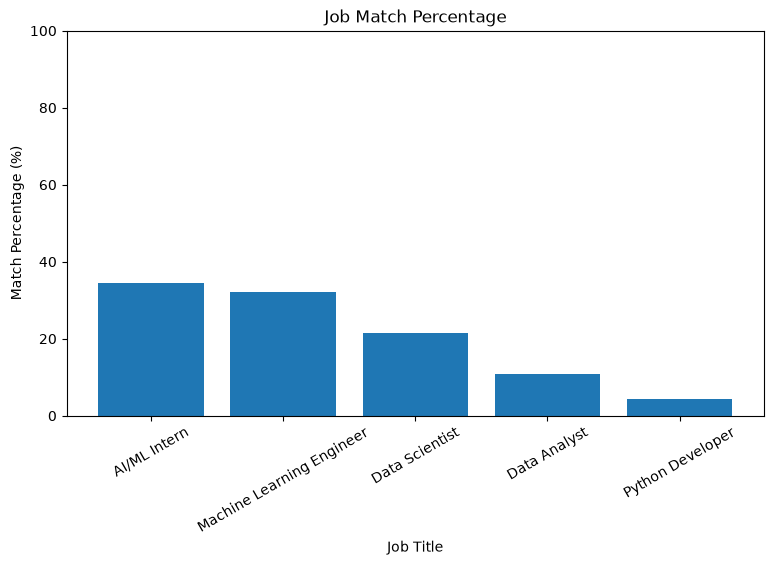

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    jobs_sorted["Job Title"],
    jobs_sorted["Match %"]
)

plt.title("Job Match Percentage")
plt.xlabel("Job Title")
plt.ylabel("Match Percentage (%)")

plt.xticks(rotation=30)
plt.ylim(0, 100)

plt.show()

In [35]:
##resume breakdown score

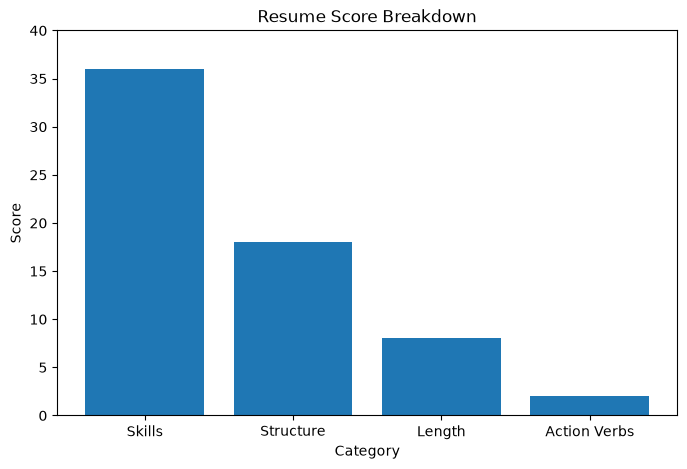

In [36]:
score_categories = [
    "Skills",
    "Structure",
    "Length",
    "Action Verbs"
]

score_values = [
    skill_score,
    structure_score,
    length_score,
    action_score
]

plt.figure(figsize=(8, 5))

plt.bar(score_categories, score_values)

plt.title("Resume Score Breakdown")
plt.xlabel("Category")
plt.ylabel("Score")

plt.ylim(0, 40)

plt.show()

In [37]:
## detected skills visualization

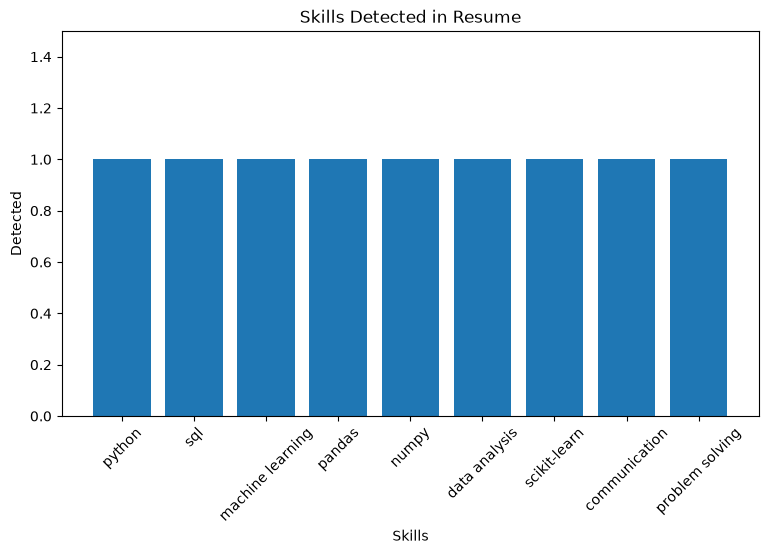

In [38]:
skill_counts = [1] * len(found_skills)

plt.figure(figsize=(9, 5))

plt.bar(found_skills, skill_counts)

plt.title("Skills Detected in Resume")
plt.xlabel("Skills")
plt.ylabel("Detected")

plt.xticks(rotation=45)
plt.ylim(0, 1.5)

plt.show()

In [39]:
## read a pdf resume

# check the pdf file name 

In [40]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'jobs.csv', 'Resume_Analyzer.ipynb', 'Shani Resume.pdf']


In [5]:
import PyPDF2

print("PyPDF2 imported successfully!")


PyPDF2 imported successfully!


In [6]:
!pip install PyPDF2

In [7]:
import PyPDF2

print("PyPDF2 imported successfully!")

PyPDF2 imported successfully!


# extacting from text

In [8]:
pdf_path = "Shani Resume.pdf"

with open(pdf_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)
    
    pdf_text = ""
    
    for page in reader.pages:
        pdf_text += page.extract_text() + "\n"

print(pdf_text)

SHAIK SHANI
 DATA ANALYST INTERN
 +91 92393 45534 | Asansol, West Bengal, India | shaikshani34@gmail.com | linkedin.com/in/shaik-shani-472491338 | github.com/ShaikShani07
PROFESSIONAL SUMMARY
B.Tech CSE (Artificial Intelligence & Machine Learning) student with a foundation in Python, Pandas, NumPy, SQL, data analysis and
machine learning concepts. Interested in data-driven problem solving and building practical AI/ML solutions. Seeking a Data Analyst
Internship to apply analytical and technical skills in a real-world environment.
EDUCATION
B.Tech – Computer Science & Engineering (Artificial Intelligence & Machine Learning)
Asansol Engineering College, Asansol, West Bengal | 2024 – 2028
Class XII – ICSE | Loreto Convent, Asansol | 2024
SKILLS
Programming: Python, C, C++, Java
Data & Analytics: Pandas, NumPy, SciPy, SQL, Data Analysis
AI/ML: Machine Learning Fundamentals, Prompt Engineering
Core CS: Data Structures & Algorithms, OOP, DBMS, Operating Systems
Tools: Git, GitHub, Tableau, M

In [9]:
#use the real resume for skill detection

In [11]:
skills = [
    "python",
    "sql",
    "machine learning",
    "pandas",
    "numpy",
    "data analysis",
    "scikit-learn",
    "tensorflow",
    "power bi",
    "excel",
    "flask",
    "git",
    "communication",
    "problem solving"
]

print("Skills list loaded successfully!")

Skills list loaded successfully!


In [12]:
resume = pdf_text

resume_lower = resume.lower()

found_skills = []

for skill in skills:
    if skill in resume_lower:
        found_skills.append(skill)

print("Skills detected from PDF resume:")
print(found_skills)

Skills detected from PDF resume:
['python', 'sql', 'machine learning', 'pandas', 'numpy', 'data analysis', 'excel', 'git', 'communication', 'problem solving']


# calculating the real resume score from my resume

In [13]:
skill_score = min(40, len(found_skills) * 4)

sections = {
    "Education": ["education", "b.tech", "bachelor"],
    "Experience": ["experience", "internship"],
    "Projects": ["projects", "project"],
    "Skills": ["skills", "technical skills"],
    "Certifications": ["certification", "certifications"]
}

section_results = {}

for section, keywords in sections.items():
    section_results[section] = any(
        keyword in resume_lower
        for keyword in keywords
    )

sections_found = sum(section_results.values())
structure_score = sections_found * 6

word_count = len(resume.split())

if 250 <= word_count <= 900:
    length_score = 20
elif 150 <= word_count < 250 or 900 < word_count <= 1200:
    length_score = 15
else:
    length_score = 8

action_verbs = [
    "developed", "built", "created", "analyzed",
    "implemented", "designed", "optimized",
    "trained", "automated", "managed"
]

action_verb_count = sum(
    verb in resume_lower
    for verb in action_verbs
)

action_score = min(10, action_verb_count * 2)

total_score = (
    skill_score
    + structure_score
    + length_score
    + action_score
)

print("================================")
print("       REAL RESUME SCORE")
print("================================")
print("Skills:        ", skill_score, "/ 40")
print("Structure:     ", structure_score, "/ 30")
print("Length:        ", length_score, "/ 20")
print("Action Verbs:  ", action_score, "/ 10")
print("--------------------------------")
print("TOTAL SCORE:   ", total_score, "/ 100")

       REAL RESUME SCORE
Skills:         40 / 40
Structure:      30 / 30
Length:         20 / 20
Action Verbs:   4 / 10
--------------------------------
TOTAL SCORE:    94 / 100


# now we will do job matching and skills missing

In [16]:
import pandas as pd

jobs = pd.DataFrame({
    "Job Title": [
        "Data Analyst",
        "Machine Learning Engineer",
        "Data Scientist",
        "Python Developer",
        "AI/ML Intern"
    ],

    "Skills": [
        "Python, SQL, Excel, Power BI, Pandas",
        "Python, Machine Learning, Scikit-learn, TensorFlow, Git",
        "Python, Pandas, NumPy, Machine Learning, Statistics",
        "Python, Flask, SQL, Git, REST API",
        "Python, Machine Learning, Pandas, NumPy, Git"
    ],

    "Job Description": [
        "Analyze business data, create reports and dashboards, clean datasets and find useful insights using Python, SQL, Pandas and Excel.",
        "Build and evaluate machine learning models, prepare datasets and develop AI solutions using Python, Machine Learning, Scikit-learn and TensorFlow.",
        "Analyze large datasets, build predictive models and communicate insights using Python, Pandas, NumPy, Machine Learning and Statistics.",
        "Develop backend applications and REST APIs using Python, Flask, SQL and Git.",
        "Assist with machine learning experiments, data preprocessing and model development using Python, Machine Learning, Pandas, NumPy and Git."
    ]
})

jobs

,Job Title,Skills,Job Description
0,Data Analyst,"Python, SQL, Excel, Power BI, Pandas","Analyze business data, create reports and dash..."
1,Machine Learning Engineer,"Python, Machine Learning, Scikit-learn, Tensor...","Build and evaluate machine learning models, pr..."
2,Data Scientist,"Python, Pandas, NumPy, Machine Learning, Stati...","Analyze large datasets, build predictive model..."
3,Python Developer,"Python, Flask, SQL, Git, REST API",Develop backend applications and REST APIs usi...
4,AI/ML Intern,"Python, Machine Learning, Pandas, NumPy, Git","Assist with machine learning experiments, data..."


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [resume] + jobs["Job Description"].tolist()

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(documents)

similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

jobs["Match %"] = (similarity_scores[0] * 100).round(2)

jobs_sorted = jobs.sort_values(
    by="Match %",
    ascending=False
)

jobs_sorted[["Job Title", "Match %"]]

,Job Title,Match %
4,AI/ML Intern,22.23
0,Data Analyst,13.84
1,Machine Learning Engineer,13.21
2,Data Scientist,10.91
3,Python Developer,3.44


In [18]:
## missing skills

In [19]:
job_skills_data = {}

for _, row in jobs.iterrows():
    required_skills = set(
        skill.strip().lower()
        for skill in row["Skills"].split(",")
    )
    
    job_skills_data[row["Job Title"]] = required_skills

print("Job skills loaded successfully!")

Job skills loaded successfully!


In [20]:
##  generating job recomendations

In [21]:
recommendations = []

for _, row in jobs_sorted.iterrows():
    
    job_title = row["Job Title"]
    
    required_skills = job_skills_data[job_title]
    missing_skills = required_skills - set(found_skills)
    
    recommendations.append({
        "Job Title": job_title,
        "Match %": row["Match %"],
        "Missing Skills": ", ".join(sorted(missing_skills))
    })

recommendations_df = pd.DataFrame(recommendations)

recommendations_df

,Job Title,Match %,Missing Skills
0,AI/ML Intern,22.23,
1,Data Analyst,13.84,power bi
2,Machine Learning Engineer,13.21,"scikit-learn, tensorflow"
3,Data Scientist,10.91,statistics
4,Python Developer,3.44,"flask, rest api"


In [22]:
improvement_recommendations = []

# Skill recommendation
if skill_score < 32:
    improvement_recommendations.append(
        "Add more relevant technical skills to your resume."
    )

# Structure recommendation
if structure_score < 24:
    improvement_recommendations.append(
        "Improve resume structure by adding clear sections such as Education, Experience, Projects and Skills."
    )

# Length recommendation
if length_score < 20:
    improvement_recommendations.append(
        "Adjust your resume length to keep it concise and focused."
    )

# Action verb recommendation
if action_score < 8:
    improvement_recommendations.append(
        "Use stronger action verbs such as Developed, Built, Designed, Implemented and Analyzed."
    )

# Missing skills recommendation
if len(recommendations_df) > 0:
    improvement_recommendations.append(
        "Review the missing skills for your top job matches and consider adding relevant skills through projects or courses."
    )

print("================================")
print(" RESUME IMPROVEMENT SUGGESTIONS")
print("================================")

for i, recommendation in enumerate(
    improvement_recommendations, 1
):
    print(f"{i}. {recommendation}")

 RESUME IMPROVEMENT SUGGESTIONS
1. Use stronger action verbs such as Developed, Built, Designed, Implemented and Analyzed.
2. Review the missing skills for your top job matches and consider adding relevant skills through projects or courses.


In [23]:
## showing the final output

In [24]:
print("=" * 50)
print("      AI RESUME ANALYZER REPORT")
print("=" * 50)

print("\nResume Score:")
print(total_score, "/ 100")

print("\nDetected Skills:")
for skill in found_skills:
    print("✓", skill)

print("\nTop Job Match:")
top_job = jobs_sorted.iloc[0]

print("Job Title:", top_job["Job Title"])
print("Match Percentage:", top_job["Match %"], "%")

required = job_skills_data[top_job["Job Title"]]
missing = required - set(found_skills)

print("\nMissing Skills:")
for skill in missing:
    print("❌", skill)

print("\nImprovement Suggestions:")
for i, suggestion in enumerate(improvement_recommendations, 1):
    print(f"{i}. {suggestion}")

print("\n" + "=" * 50)

      AI RESUME ANALYZER REPORT

Resume Score:
94 / 100

Detected Skills:
✓ python
✓ sql
✓ machine learning
✓ pandas
✓ numpy
✓ data analysis
✓ excel
✓ git
✓ communication
✓ problem solving

Top Job Match:
Job Title: AI/ML Intern
Match Percentage: 22.23 %

Missing Skills:

Improvement Suggestions:
1. Use stronger action verbs such as Developed, Built, Designed, Implemented and Analyzed.
2. Review the missing skills for your top job matches and consider adding relevant skills through projects or courses.

